Atividade Semana 4 – Transformação dos Dados

Aplicar as principais técnicas de Transformação utilizando uma base de dados, nomeada dataset_estudantes_tranformacao com informações de estudantes de um curso de graduação.

1. Normalização

• Aplique os três métodos de normalização nos atributos
Nota_Matematica e Nota_Programacao:

a) Normalização Simples

b) MinMax

c) Padronização (Z-score)

2. Agregação

• Organize os dados do dataset por Curso e calcule:

a) A média de Nota_Matematica por grupo

b) Quantidade de estudantes por grupo

• Apresente os resultados com gráficos de barras

3. Criação de novos atributos

• A criação de novos atributos consiste na criação de novas colunas
no dataset. Esses atributos são gerados a partir dos existentes.

• Nesse contexto, crie os seguintes atributos:

a) Idade (a partir da Data_Nascimento)

b) Média_Geral das notas (considerando todas as notas

(Matematica, Programação, Estatística)

c) Faixa de Desempenho: Alta (>=8), Média (5 a 7.99), Baixa (<5)

• Justifique como esses atributos auxiliam na análise dos dados.

4. Redução sintetizada dos dados

• Identifique registros duplicados com base em Nome + Data_Nascimento + Curso.

• Remova os duplicados mantendo apenas o primeiro.

• Informe quantos registros foram removidos.

In [43]:
#Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

In [7]:
#Importar Arquivo Excel
df = pd.read_excel("/home/pedrofelipe/Documentos/Data Py/dataset_estudantes_transformacao.xlsx", skiprows = 1)
df.head()

,ID_Estudante,Nome,Data_Nascimento,Curso,Ano_Ingresso,Nota_Matematica,Nota_Programacao,Nota_Estatistica,Total_Horas_Estudadas,Numero_Faltas
0,181,Luiz Miguel Aragão,1980-12-06,Sistemas de Informação,2022,3.41,6.29,6.94,403.9,9
1,155,João Guilherme Santos,1983-10-11,Ciência da Computação,2021,9.86,1.11,1.39,499.1,9
2,112,Lívia Mendes,2002-10-24,Engenharia de Software,2023,1.61,9.50,5.96,494.5,27
3,248,Sra. Elisa Cardoso,1985-12-09,Engenharia de Software,2023,9.67,6.72,9.97,346.3,21
4,61,Gabriela Fernandes,1967-08-02,Ciência da Computação,2023,3.89,3.88,3.56,87.3,14


In [8]:
#Aplicar Normalização de Notas
# a) Normalização Simples
df["NormSimples_Matematica"] = df["Nota_Matematica"]/df["Nota_Matematica"].max()
df["NormSimples_Programacao"] = df["Nota_Programacao"]/df["Nota_Programacao"].max()

In [11]:
# b) Min-Max
df["MinMax_Matematica"] = (df["Nota_Matematica"] - df["Nota_Matematica"].min()) / (df["Nota_Matematica"].max() - df["Nota_Matematica"].min())
df["MinMax_Programacao"] = (df["Nota_Programacao"] - df["Nota_Programacao"].min()) / (df["Nota_Programacao"].max() - df["Nota_Programacao"].min())

In [13]:
# c) Padronização (Z-score)
df["PadZ_Matematica"] = (df["Nota_Matematica"] - df["Nota_Matematica"].mean()) / df["Nota_Matematica"].std()
df["PadZ_Programacao"] = (df["Nota_Programacao"] - df["Nota_Programacao"].mean()) / df["Nota_Programacao"].std()

In [21]:
#Agregar por curso
agrup = df.groupby("Curso").agg(
    MediaNota_Matematica = ("Nota_Matematica", "mean"),
    Qtd_Estudantes = ("ID_Estudante", "count")
).reset_index()

agrup

,Curso,MediaNota_Matematica,Qtd_Estudantes
0,ADS,5.316479,71
1,Ciência da Computação,5.003571,70
2,Engenharia de Software,4.690133,75
3,Sistemas de Informação,4.893820,89


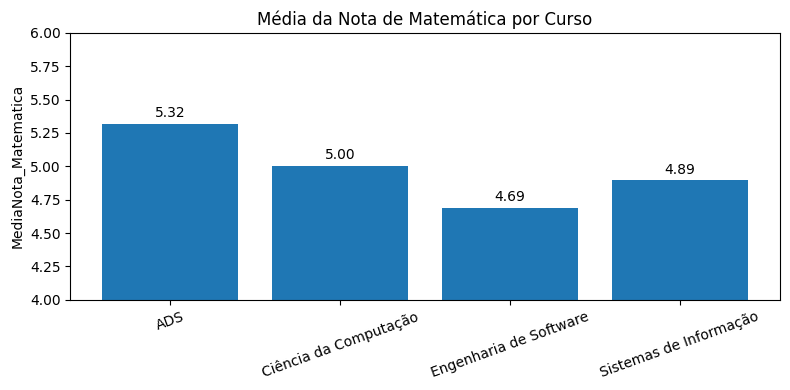

In [ ]:
#Plotar em Graficos
#a) A média de Nota_Matematica por grupo
plt.figure(figsize = (8,4))
plt.bar(agrup["Curso"], agrup["MediaNota_Matematica"])
plt.ylim(4,6)

for i, v in enumerate(agrup["MediaNota_Matematica"]):
    plt.text(i, v + 0.05, f"{v:.2f}", ha='center')

plt.xticks(rotation = 20)
plt.ylabel("MediaNota_Matematica")
plt.title("Média da Nota de Matemática por Curso")
plt.tight_layout()
plt.show()

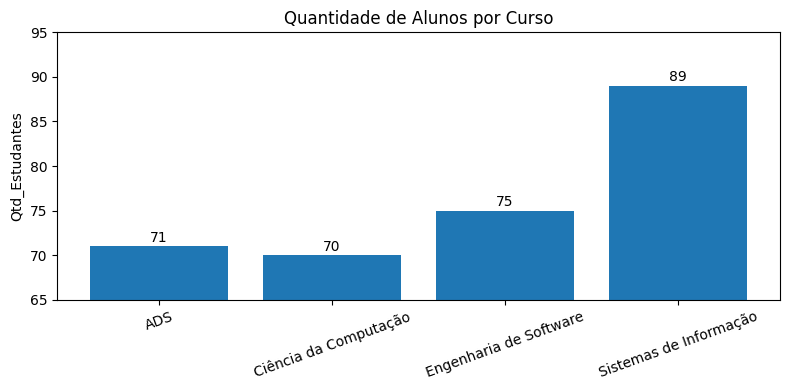

In [ ]:
#b) Quantidade de estudantes por grupo
plt.figure(figsize = (8,4))
plt.bar(agrup["Curso"], agrup["Qtd_Estudantes"])
plt.ylim(65,95)

for i, v in enumerate(agrup["Qtd_Estudantes"]):
    plt.text(i, v + 0.5, f"{v}", ha='center')

plt.xticks(rotation = 20)
plt.ylabel("Qtd_Estudantes")
plt.title("Quantidade de Alunos por Curso")
plt.tight_layout()
plt.show()

In [46]:
#Criação de Novos Atributos
#a) Idade
df["Data_Nascimento"] = pd.to_datetime(df["Data_Nascimento"])
hoje = pd.to_datetime("today")
df["Idade"] = (hoje - df["Data_Nascimento"]).dt.days // 365

In [48]:
#b) Média_Geral das notas
df["Media_Geral"] = df[["Nota_Matematica", "Nota_Programacao", "Nota_Estatistica", ]].mean(axis=1)

In [50]:
#c) Faixa de Desempenho: Alta (>=8), Média (5 a 7.99), Baixa (<5)
def classificar(media):
    if media >= 8:
        return "Alta"
    elif media >= 5:
        return "Média"
    else:
        return "Baixa"

df["Faixa_Desemp"] = df["Media_Geral"].apply(classificar)

In [ ]:
#Redução de dados
#Verificar duplicados
dupl = df.duplicated(subset = ["Nome", "Data_Nascimento", "Curso"], keep = "first")
dupl.sum()

In [51]:
df.head()

,ID_Estudante,Nome,Data_Nascimento,Curso,Ano_Ingresso,Nota_Matematica,Nota_Programacao,Nota_Estatistica,Total_Horas_Estudadas,Numero_Faltas,NormSimples_Matematica,NormSimples_Programacao,MinMax_Matematica,MinMax_Programacao,PadZ_Matematica,PadZ_Programacao,Idade,Media_Geral,Faixa_Desemp
0,181,Luiz Miguel Aragão,1980-12-06,Sistemas de Informação,2022,3.41,6.29,6.94,403.9,9,0.344444,0.629,0.341117,0.624874,-0.529711,0.393599,45,5.546667,Média
1,155,João Guilherme Santos,1983-10-11,Ciência da Computação,2021,9.86,1.11,1.39,499.1,9,0.995960,0.111,0.995939,0.101112,1.664220,-1.327016,42,4.120000,Baixa
2,112,Lívia Mendes,2002-10-24,Engenharia de Software,2023,1.61,9.50,5.96,494.5,27,0.162626,0.950,0.158376,0.949444,-1.141970,1.459849,23,5.690000,Média
3,248,Sra. Elisa Cardoso,1985-12-09,Engenharia de Software,2023,9.67,6.72,9.97,346.3,21,0.976768,0.672,0.976650,0.668352,1.599593,0.536430,40,8.786667,Alta
4,61,Gabriela Fernandes,1967-08-02,Ciência da Computação,2023,3.89,3.88,3.56,87.3,14,0.392929,0.388,0.389848,0.381193,-0.366441,-0.406919,58,3.776667,Baixa
